# Clase 7 · Evaluar y regularizar modelos

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

**Qué hacemos hoy.** Dos mitades. En la primera volvemos a los 10.000 clientes de tarjeta de crédito de la clase 6 y medimos por separado los dos errores del clasificador (sensibilidad, especificidad y precisión), elegimos el umbral según el costo de cada error y comparamos modelos con la curva ROC. En la segunda volvemos a la regresión lineal con los salarios de 263 jugadores de béisbol y 19 variables: vemos cómo mínimos cuadrados se ajusta al azar de su muestra, y cómo Ridge y Lasso lo corrigen. Los dos ejemplos son del libro de James, Witten, Hastie y Tibshirani.

**El hilo de la clase:** un modelo se juzga por sus errores donde importan, con el costo correcto y en datos que no vio.

## 1. Preparación

Las bibliotecas de siempre, más **scikit-learn** (se importa como `sklearn`), la biblioteca de aprendizaje automático de Python. Hoy la usamos para la curva ROC, para separar los datos, para estandarizar y para Ridge y Lasso.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# scikit-learn: la biblioteca de aprendizaje automático de Python
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV

sns.set_theme(style="whitegrid")
%config InlineBackend.figure_format = "retina"
pd.options.display.float_format = "{:.3f}".format

In [2]:
# Datos locales del repositorio clonado
BASE = "datos/"
# Alternativa por URL, si no tiene el repositorio clonado:
# BASE = "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/main/datos/"

## 2. Recordatorio: la matriz de confusión de la clase 6

**Objetivo:** volver a tener el modelo de la deuda y su matriz de confusión, que es de donde salen todas las medidas de hoy.

Los mismos pasos de la clase 6: la columna `no_paga` vale 1 si el cliente dejó de pagar, la deuda en cientos de dólares, y la regresión logística.

In [3]:
clientes = pd.read_csv(BASE + "clase06/default_islr.csv")
clientes["no_paga"] = (clientes["default"] == "Yes").astype(int)
clientes["deuda_100"] = clientes["balance"] / 100
clientes.head()

,default,student,balance,income,no_paga,deuda_100
0,No,No,729.526,44361.625,0,7.295
1,No,Yes,817.180,12106.135,0,8.172
2,No,No,1073.549,31767.139,0,10.735
3,No,No,529.251,35704.494,0,5.293
4,No,No,785.656,38463.496,0,7.857


In [4]:
logistica = smf.logit("no_paga ~ deuda_100", data=clientes).fit(disp=0)
clientes["prob"] = logistica.predict(clientes)                  # probabilidad de no pagar
clientes["prediccion"] = (clientes["prob"] >= 0.5).astype(int)  # umbral 0,5
clientes[["balance", "no_paga", "prob", "prediccion"]].head()

,balance,no_paga,prob,prediccion
0,729.526,0,0.001,0
1,817.180,0,0.002,0
2,1073.549,0,0.009,0
3,529.251,0,0.000,0
4,785.656,0,0.002,0


In [5]:
# La matriz de confusión: lo real en las filas, lo predicho en las columnas
matriz = pd.crosstab(clientes["no_paga"], clientes["prediccion"], rownames=["real"], colnames=["predicho"])
matriz

predicho,0,1
real,,
0,9625,42
1,233,100


Para calcular las medidas conviene tener las cuatro celdas como números. `matriz.loc[fila, columna]` toma una celda: la fila es lo real y la columna lo predicho, así que `matriz.loc[1, 1]` son los clientes que no pagaron y el modelo declaró morosos.

In [6]:
VP = matriz.loc[1, 1]   # verdadero positivo: no pagó y el modelo dijo "no paga"
FN = matriz.loc[1, 0]   # falso negativo: no pagó y el modelo dijo "paga"
FP = matriz.loc[0, 1]   # falso positivo: pagó y el modelo dijo "no paga"
VN = matriz.loc[0, 0]   # verdadero negativo: pagó y el modelo dijo "paga"
print(f"VP = {VP}, FN = {FN}, FP = {FP}, VN = {VN}")

VP = 100, FN = 233, FP = 42, VN = 9625


In [7]:
exactitud = (VP + VN) / len(clientes)
base = 1 - clientes["no_paga"].mean()   # decir siempre "paga"
print(f"exactitud del modelo: {exactitud:.3f}")
print(f"decir siempre \"paga\": {base:.3f}")

exactitud del modelo: 0.973
decir siempre "paga": 0.967


Casi lo mismo: la exactitud mezcla los dos errores y, como el sí es raro, queda dominada por los que pagan. Hoy medimos cada error por separado.

## 3. Sensibilidad, especificidad y precisión

**Objetivo:** medir cada error por separado con tres fracciones de la matriz.

**Sensibilidad** (en inglés, *recall*): de los clientes que no pagan, ¿qué fracción detecta el modelo? Mira la fila de los que no pagan:

$$\text{sensibilidad} = \frac{VP}{VP + FN}$$

In [8]:
sensibilidad = VP / (VP + FN)
print(f"sensibilidad = {VP} / ({VP} + {FN}) = {sensibilidad:.2f}")

sensibilidad = 100 / (100 + 233) = 0.30


El modelo detecta 3 de cada 10 clientes que no pagan.

**Especificidad**: de los clientes que pagan, ¿qué fracción deja en paz? Mira la fila de los que pagan:

$$\text{especificidad} = \frac{VN}{VN + FP}$$

In [9]:
especificidad = VN / (VN + FP)
print(f"especificidad = {VN} / ({VN} + {FP}) = {especificidad:.3f}")

especificidad = 9625 / (9625 + 42) = 0.996


**Precisión** (en inglés, *precision*): de los clientes que el modelo declara morosos, ¿qué fracción lo es? Mira la columna del predicho "no paga":

$$\text{precisión} = \frac{VP}{VP + FP}$$

In [10]:
precision = VP / (VP + FP)
print(f"precisión = {VP} / ({VP} + {FP}) = {precision:.2f}")

precisión = 100 / (100 + 42) = 0.70


De cada 10 clientes que el modelo declara morosos, 7 lo son. Resumen: el modelo casi no molesta a los que pagan (especificidad 0,996), cuando marca a alguien suele acertar (precisión 0,70), pero se le escapan 7 de cada 10 morosos (sensibilidad 0,30).

## 4. Mover el umbral

**Objetivo:** ver qué pasa con los errores si se dice "no paga" desde otra probabilidad.

El modelo no cambia: solo cambia el corte. Con umbral 0,2:

In [11]:
prediccion_02 = (clientes["prob"] >= 0.2).astype(int)
pd.crosstab(clientes["no_paga"], prediccion_02, rownames=["real"], colnames=["predicho"])

predicho,0,1
real,,
0,9404,263
1,134,199


Se detectan 199 morosos en vez de 100, a cambio de 263 falsos positivos en vez de 42. Para repetir el cálculo con varios umbrales sin copiar código, una función que recibe un umbral y devuelve las cuatro celdas y las medidas. Hace exactamente los pasos anteriores, contando cada celda con una condición:

In [12]:
def medidas(umbral):
    """Las cuatro celdas de la matriz y las medidas, para un umbral."""
    predicho = (clientes["prob"] >= umbral).astype(int)
    real = clientes["no_paga"]
    VP = ((real == 1) & (predicho == 1)).sum()
    FN = ((real == 1) & (predicho == 0)).sum()
    FP = ((real == 0) & (predicho == 1)).sum()
    VN = ((real == 0) & (predicho == 0)).sum()
    return {"umbral": umbral, "VP": VP, "FN": FN, "FP": FP, "VN": VN,
            "sensibilidad": VP / (VP + FN), "especificidad": VN / (VN + FP)}

medidas(0.5)

{'umbral': 0.5,
 'VP': np.int64(100),
 'FN': np.int64(233),
 'FP': np.int64(42),
 'VN': np.int64(9625),
 'sensibilidad': np.float64(0.3003003003003003),
 'especificidad': np.float64(0.9956553222302679)}

In [13]:
tabla_umbrales = pd.DataFrame([medidas(u) for u in [0.5, 0.3, 0.2, 0.1]])
tabla_umbrales

,umbral,VP,FN,FP,VN,sensibilidad,especificidad
0,0.500,100,233,42,9625,0.300,0.996
1,0.300,167,166,147,9520,0.502,0.985
2,0.200,199,134,263,9404,0.598,0.973
3,0.100,244,89,550,9117,0.733,0.943


Con todos los umbrales entre 0,01 y 0,98 se ve el balance completo: bajar el umbral sube la sensibilidad y baja la especificidad.

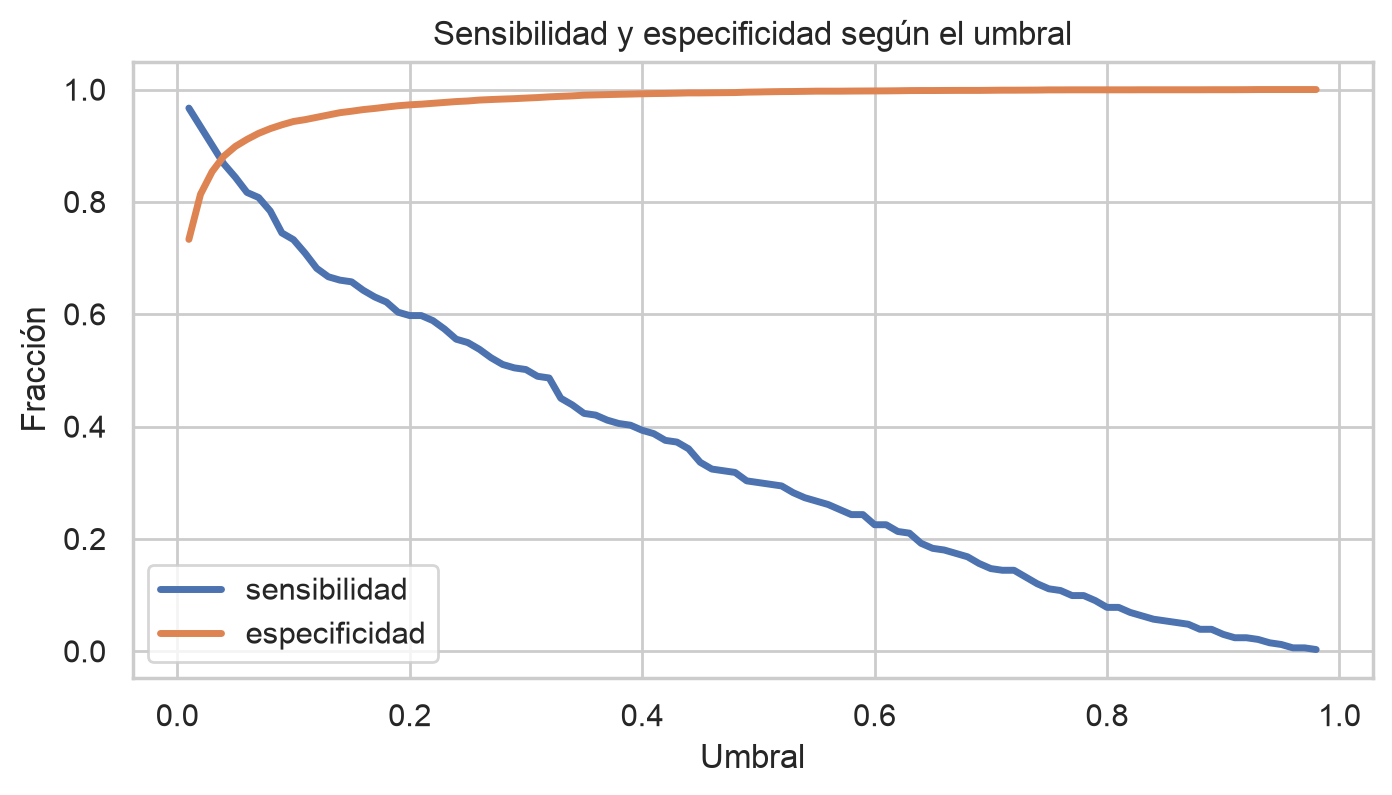

In [14]:
umbrales = np.round(np.arange(0.01, 0.99, 0.01), 2)
curva = pd.DataFrame([medidas(u) for u in umbrales])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curva["umbral"], curva["sensibilidad"], lw=2.5, label="sensibilidad")
ax.plot(curva["umbral"], curva["especificidad"], lw=2.5, label="especificidad")
ax.set(xlabel="Umbral", ylabel="Fracción", title="Sensibilidad y especificidad según el umbral")
ax.legend()
plt.show()

## 5. El costo de cada error

**Objetivo:** elegir el umbral según lo que cuesta cada error.

**Supuesto** (en un proyecto real lo define el problema): darle la tarjeta a un cliente que no paga, un falso negativo, cuesta 10; negársela a uno que sí paga, un falso positivo, cuesta 1. El costo total de un umbral es:

$$\text{costo total} = 10 \cdot FN + 1 \cdot FP$$

In [15]:
costo_fn = 10
costo_fp = 1
tabla_umbrales["costo"] = costo_fn * tabla_umbrales["FN"] + costo_fp * tabla_umbrales["FP"]
tabla_umbrales[["umbral", "FN", "FP", "costo"]]

,umbral,FN,FP,costo
0,0.500,233,42,2372
1,0.300,166,147,1807
2,0.200,134,263,1603
3,0.100,89,550,1440


El umbral 0,5 es el más caro de los cuatro. Con todos los umbrales, el de menor costo:

umbral de menor costo: 0.08, con costo 1393


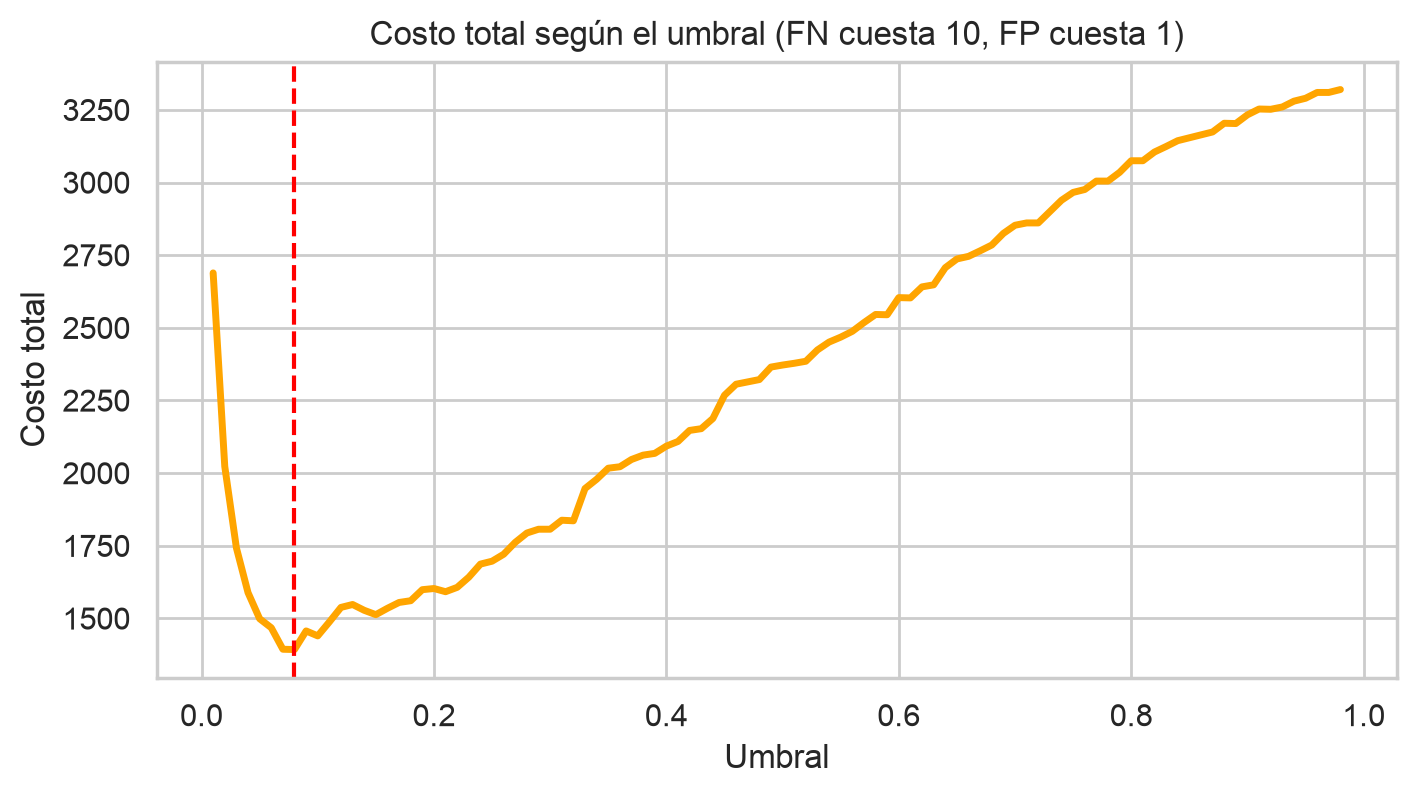

In [16]:
curva["costo"] = costo_fn * curva["FN"] + costo_fp * curva["FP"]
mejor = curva.loc[curva["costo"].idxmin()]   # la fila con el menor costo
print(f"umbral de menor costo: {mejor['umbral']:.2f}, con costo {mejor['costo']:.0f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curva["umbral"], curva["costo"], lw=2.5, color="orange")
ax.axvline(mejor["umbral"], color="red", ls="--")
ax.set(xlabel="Umbral", ylabel="Costo total", title="Costo total según el umbral (FN cuesta 10, FP cuesta 1)")
plt.show()

**De dónde sale ese umbral.** $P$ no es el umbral: es la probabilidad de no pagar que el modelo le da a cada cliente. Con esa $P$ se calcula cuánto cuesta en promedio cada decisión. Aprobar cuesta 10 si el cliente no paga, lo que pasa con probabilidad $P$: en promedio, $P \cdot 10$. Rechazar cuesta 1 si iba a pagar, lo que pasa con probabilidad $1 - P$: en promedio, $(1 - P) \cdot 1$. Con tres clientes:

In [17]:
tres = pd.DataFrame({"cliente": ["A", "B", "C"], "P": [0.05, 1 / 11, 0.30]})
tres["costo de aprobar"] = tres["P"] * costo_fn          # P · 10
tres["costo de rechazar"] = (1 - tres["P"]) * costo_fp   # (1 − P) · 1
aprobar, rechazar = tres["costo de aprobar"].round(3), tres["costo de rechazar"].round(3)
tres["conviene"] = "da lo mismo"
tres.loc[aprobar < rechazar, "conviene"] = "aprobar"
tres.loc[aprobar > rechazar, "conviene"] = "rechazar"
tres

,cliente,P,costo de aprobar,costo de rechazar,conviene
0,A,0.050,0.500,0.950,aprobar
1,B,0.091,0.909,0.909,da lo mismo
2,C,0.300,3.000,0.700,rechazar


Al cliente A conviene aprobarlo y al C rechazarlo. Con el B, que tiene $P = 1/11$, las dos decisiones cuestan lo mismo: ese es el umbral. En general, conviene rechazar cuando el costo de aprobar supera al de rechazar, y despejando $P$ queda la regla:

$$\text{umbral} = \frac{\text{costo FP}}{\text{costo FP} + \text{costo FN}}$$

In [18]:
print(f"costos 10 y 1: umbral = 1 / (1 + 10) = {costo_fp / (costo_fp + costo_fn):.3f}")
print(f"costos iguales: umbral = 1 / (1 + 1) = {1 / (1 + 1):.3f}")

costos 10 y 1: umbral = 1 / (1 + 10) = 0.091
costos iguales: umbral = 1 / (1 + 1) = 0.500


La regla da 0,09, cerca del 0,08 que encontró la búsqueda. Y con costos iguales da 0,5: el umbral por defecto supone que los dos errores cuestan lo mismo.

## 6. La curva ROC y el AUC

**Objetivo:** comparar dos modelos sin tener que elegir un umbral.

El umbral se elige con los costos, pero antes hay que elegir el modelo. Para comparar, un segundo modelo más pobre: solo con la variable estudiante.

In [19]:
clientes["estudiante"] = (clientes["student"] == "Yes").astype(int)
solo_estudiante = smf.logit("no_paga ~ estudiante", data=clientes).fit(disp=0)
clientes["prob_estudiante"] = solo_estudiante.predict(clientes)

Con el umbral 0,5, ¿cuál de los dos es mejor? Una función calcula la sensibilidad y la especificidad a partir de lo real y lo predicho:

In [20]:
def sensibilidad_especificidad(real, predicho):
    sensibilidad = ((real == 1) & (predicho == 1)).sum() / (real == 1).sum()
    especificidad = ((real == 0) & (predicho == 0)).sum() / (real == 0).sum()
    print(f"sensibilidad {sensibilidad:.3f}   especificidad {especificidad:.3f}")


real = clientes["no_paga"]
predicho_deuda = (clientes["prob"] >= 0.5).astype(int)
predicho_estudiante = (clientes["prob_estudiante"] >= 0.5).astype(int)

print("Con la deuda:")
sensibilidad_especificidad(real, predicho_deuda)
print("Solo con estudiante:")
sensibilidad_especificidad(real, predicho_estudiante)

Con la deuda:
sensibilidad 0.300   especificidad 0.996
Solo con estudiante:
sensibilidad 0.000   especificidad 1.000


Cada modelo gana en una medida: el de la deuda detecta más morosos, y el de estudiante no molesta a ningún buen cliente, porque no detecta a nadie (todas sus probabilidades son menores que 0,5). Con otro umbral los números cambian. Para comparar sin elegir un umbral está la **curva ROC**.

La curva ROC dibuja, para cada umbral, la sensibilidad (la fracción de morosos detectados) contra 1 − especificidad (la fracción de buenos clientes molestados, es decir, de los que pagan que el modelo declara morosos). `roc_curve` recibe lo real y la probabilidad, y devuelve las dos coordenadas para todos los umbrales:

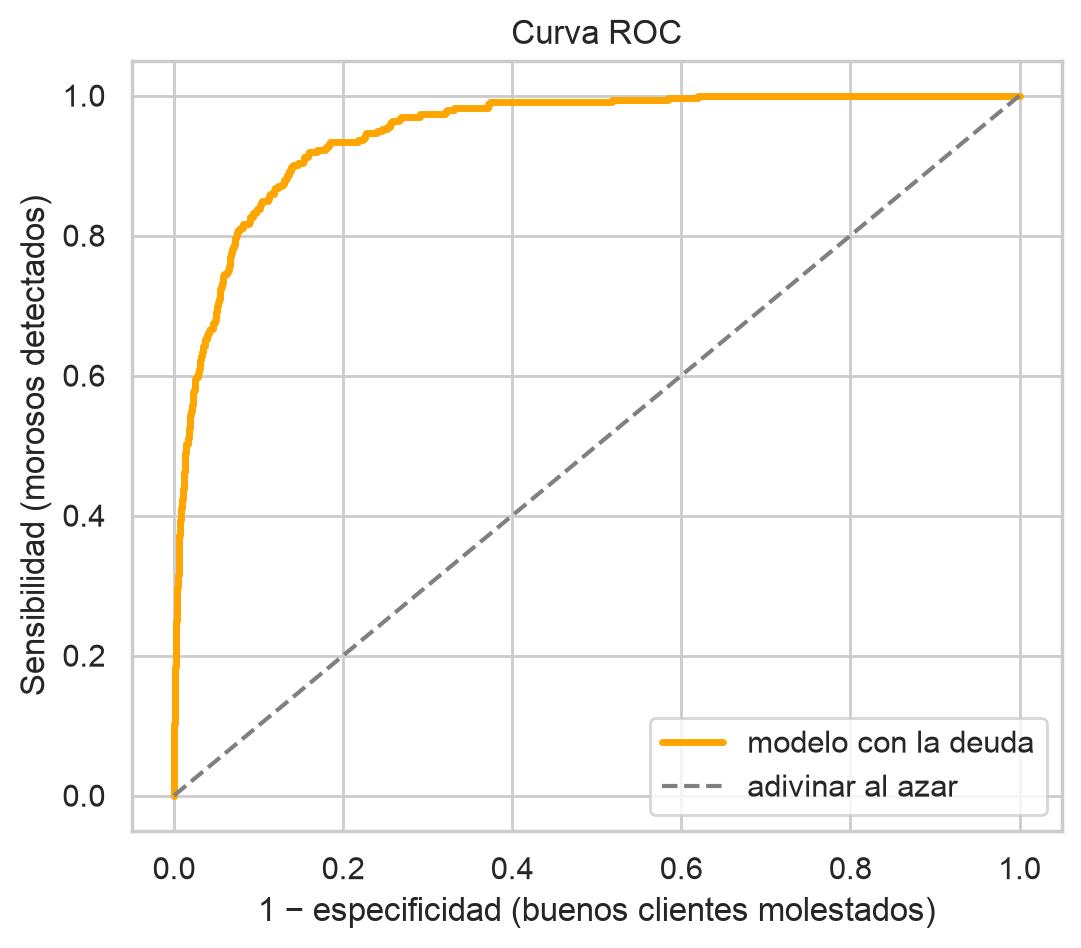

In [21]:
x_roc, y_roc, umbrales_roc = roc_curve(clientes["no_paga"], clientes["prob"])
# x_roc: 1 − especificidad; y_roc: sensibilidad; un valor por umbral

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(x_roc, y_roc, lw=2.5, color="orange", label="modelo con la deuda")
ax.plot([0, 1], [0, 1], "--", color="gray", label="adivinar al azar")
ax.set(xlabel="1 − especificidad (buenos clientes molestados)",
       ylabel="Sensibilidad (morosos detectados)", title="Curva ROC")
ax.legend()
plt.show()

**Cómo se lee.** Cada punto de la curva es un umbral, y bajar el umbral sube por la curva: más morosos detectados y más buenos clientes molestados. Lo ideal es la esquina de arriba a la izquierda (detectar a todos sin molestar a nadie) y la diagonal es adivinar al azar: mientras más se acerca la curva a esa esquina, mejor separa el modelo.

Un ejemplo de lectura: para detectar al menos al 80% de los morosos, ¿a cuántos buenos clientes hay que molestar? `np.argmax` da la posición del primer valor que cumple la condición:

In [22]:
posicion = np.argmax(y_roc >= 0.8)

print("umbral:", round(umbrales_roc[posicion], 3))
print("sensibilidad:", round(y_roc[posicion], 3))
print("1 − especificidad:", round(x_roc[posicion], 3))

umbral: 0.074
sensibilidad: 0.802
1 − especificidad: 0.074


Con umbral 0,074 el modelo detecta al 80% de los morosos y molesta al 7% de los buenos clientes. Ahora las dos curvas en el mismo gráfico:

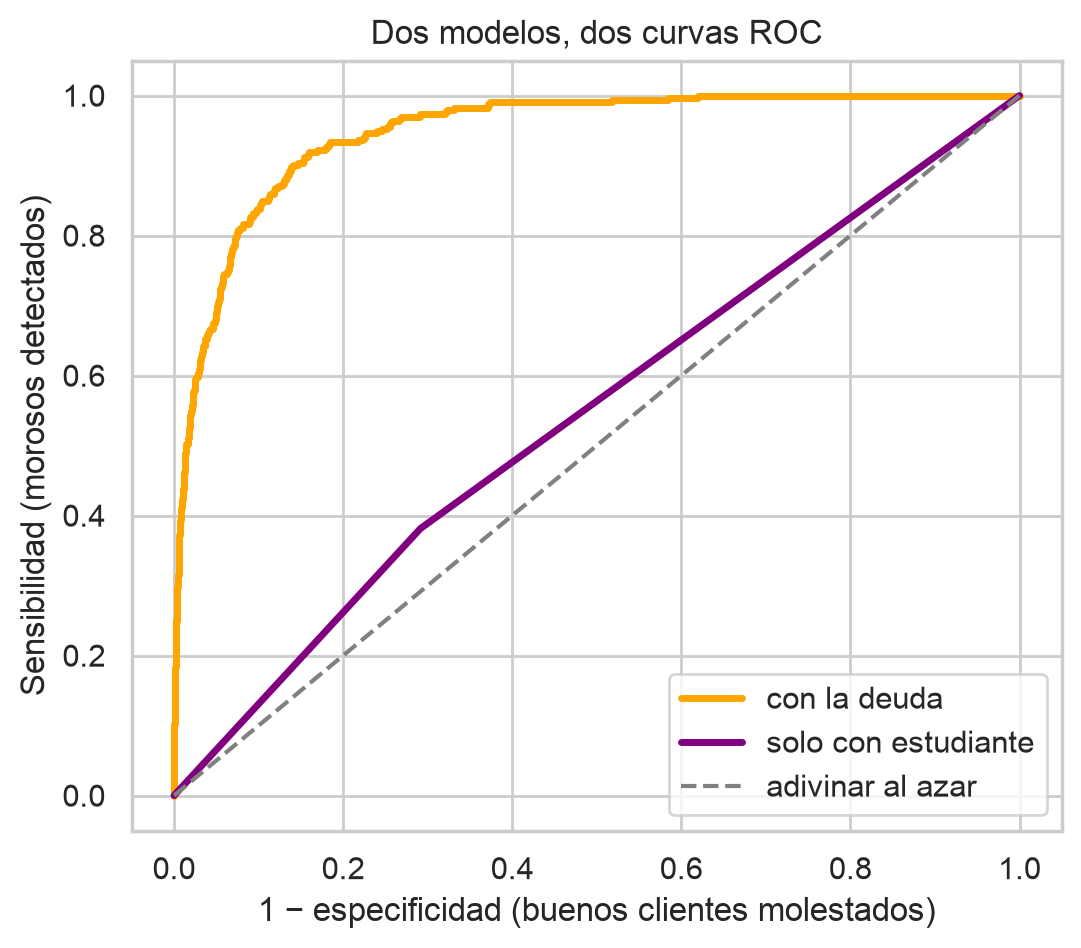

In [23]:
x_est, y_est, _ = roc_curve(clientes["no_paga"], clientes["prob_estudiante"])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(x_roc, y_roc, lw=2.5, color="orange", label="con la deuda")
ax.plot(x_est, y_est, lw=2.5, color="purple", label="solo con estudiante")
ax.plot([0, 1], [0, 1], "--", color="gray", label="adivinar al azar")
ax.set(xlabel="1 − especificidad (buenos clientes molestados)",
       ylabel="Sensibilidad (morosos detectados)", title="Dos modelos, dos curvas ROC")
ax.legend()
plt.show()

El modelo de estudiante da solo dos probabilidades, una para los estudiantes y otra para el resto, así que su curva tiene un solo quiebre. Sus puntos:

In [24]:
print("1 − especificidad:", x_est.round(3))
print("sensibilidad:     ", y_est.round(3))

1 − especificidad: [0.    0.291 1.   ]
sensibilidad:      [0.    0.381 1.   ]


El quiebre es rechazar a todos los estudiantes: detecta al 38% de los morosos y molesta al 29% de los buenos clientes. Con ese mismo 29%, la curva de la deuda está en 97%. La curva de la deuda va siempre por encima: ese modelo es mejor con cualquier umbral, sin importar los costos.

El **AUC** (área bajo la curva) resume la comparación en un número entre 0,5 (adivinar) y 1 (separar perfecto): mientras más alta la curva, mayor el área. Se lee así: si se toma al azar un cliente que no paga y uno que paga, el AUC es la fracción de esos pares en que el modelo le da más probabilidad al que no paga.

In [25]:
auc_deuda = roc_auc_score(clientes["no_paga"], clientes["prob"])
auc_estudiante = roc_auc_score(clientes["no_paga"], clientes["prob_estudiante"])

print(f"AUC del modelo con la deuda: {auc_deuda:.3f}")
print(f"AUC del modelo solo con estudiante: {auc_estudiante:.3f}")

AUC del modelo con la deuda: 0.948
AUC del modelo solo con estudiante: 0.545


## 7. Otro problema: el salario de jugadores de béisbol

**Objetivo:** tener un problema de regresión con muchas variables.

Los datos `Hitters` son del laboratorio de Ridge y Lasso del libro (sección 6.6): jugadores de las grandes ligas de béisbol de Estados Unidos, con sus estadísticas de la temporada 1986 y de toda su carrera, y su salario de 1987 en miles de dólares. Las columnas vienen en inglés; las renombramos:

| original | nombre nuevo | qué es |
|---|---|---|
| AtBat, Hits, HmRun | turnos, hits, jonrones | turnos al bate, hits y jonrones en 1986 |
| Runs, RBI, Walks | anotadas, impulsadas, bases_bolas | carreras anotadas e impulsadas y bases por bolas en 1986 |
| Years | temporadas | años en las grandes ligas |
| CAtBat, CHits, CHmRun, CRuns, CRBI, CWalks | los mismos con `_carrera` | los mismos totales, acumulados en toda la carrera |
| PutOuts, Assists, Errors | outs_defensa, asistencias, errores | jugadas en defensa en 1986 |
| League, Division, NewLeague | liga_nacional, division_oeste, liga_nacional_1987 | dummies: liga y división en 1986, y liga en 1987 |
| Salary | salario | la respuesta, en miles de dólares |

In [26]:
jugadores = pd.read_csv(BASE + "clase07/hitters_islr.csv")
print("filas y columnas:", jugadores.shape)
print("jugadores sin salario:", jugadores["Salary"].isna().sum())
jugadores.head()

filas y columnas: (322, 20)
jugadores sin salario: 59


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.000,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.000,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.000,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.500,N


Se quitan los jugadores sin salario, porque el salario es lo que queremos explicar, y se renombran las columnas.

In [27]:
jugadores = jugadores.dropna(subset=["Salary"])

nombres = {
    "AtBat": "turnos", "Hits": "hits", "HmRun": "jonrones", "Runs": "anotadas", "RBI": "impulsadas",
    "Walks": "bases_bolas", "Years": "temporadas", "CAtBat": "turnos_carrera", "CHits": "hits_carrera",
    "CHmRun": "jonrones_carrera", "CRuns": "anotadas_carrera", "CRBI": "impulsadas_carrera",
    "CWalks": "bases_bolas_carrera", "PutOuts": "outs_defensa", "Assists": "asistencias", "Errors": "errores",
}
X = jugadores.rename(columns=nombres)[list(nombres.values())].astype(float)
X["liga_nacional"] = (jugadores["League"] == "N").astype(float)
X["division_oeste"] = (jugadores["Division"] == "W").astype(float)
X["liga_nacional_1987"] = (jugadores["NewLeague"] == "N").astype(float)
y = jugadores["Salary"]

print("jugadores:", len(X), "| variables:", X.shape[1])
X.head()

jugadores: 263 | variables: 19


,turnos,hits,jonrones,anotadas,impulsadas,bases_bolas,temporadas,turnos_carrera,hits_carrera,jonrones_carrera,anotadas_carrera,impulsadas_carrera,bases_bolas_carrera,outs_defensa,asistencias,errores,liga_nacional,division_oeste,liga_nacional_1987
1,315.000,81.000,7.000,24.000,38.000,39.000,14.000,3449.000,835.000,69.000,321.000,414.000,375.000,632.000,43.000,10.000,1.000,1.000,1.000
2,479.000,130.000,18.000,66.000,72.000,76.000,3.000,1624.000,457.000,63.000,224.000,266.000,263.000,880.000,82.000,14.000,0.000,1.000,0.000
3,496.000,141.000,20.000,65.000,78.000,37.000,11.000,5628.000,1575.000,225.000,828.000,838.000,354.000,200.000,11.000,3.000,1.000,0.000,1.000
4,321.000,87.000,10.000,39.000,42.000,30.000,2.000,396.000,101.000,12.000,48.000,46.000,33.000,805.000,40.000,4.000,1.000,0.000,1.000
5,594.000,169.000,4.000,74.000,51.000,35.000,11.000,4408.000,1133.000,19.000,501.000,336.000,194.000,282.000,421.000,25.000,0.000,1.000,0.000


Muchas de estas variables dicen casi lo mismo: un jugador con más temporadas tiene más de todo en su carrera.

In [28]:
X[["temporadas", "turnos_carrera", "hits_carrera"]].corr()

,temporadas,turnos_carrera,hits_carrera
temporadas,1.000,0.916,0.898
turnos_carrera,0.916,1.000,0.995
hits_carrera,0.898,0.995,1.000


## 8. Entrenamiento, prueba y el RMSE

**Objetivo:** medir el error de mínimos cuadrados en datos que no vio.

Como en la clase 6, se separan los datos al azar antes de ajustar. `train_test_split` hace el reparto: `test_size=0.5` deja la mitad para prueba, como en el laboratorio del libro, y `random_state=1` fija la semilla para que el reparto sea siempre el mismo.

In [29]:
X_ent, X_pru, y_ent, y_pru = train_test_split(X, y, test_size=0.5, random_state=1)
print("entrenamiento:", len(X_ent), "jugadores | prueba:", len(X_pru), "jugadores")

entrenamiento: 131 jugadores | prueba: 132 jugadores


**Estandarizar.** Antes de comparar coeficientes, y sobre todo antes de penalizarlos, todas las variables deben estar en la misma escala: a cada una se le resta su media y se divide por su desviación estándar,

$$z = \frac{x - \text{media}}{\text{desviación estándar}}$$

`StandardScaler` hace esa cuenta. Con `fit` calcula la media y la desviación **solo con los datos de entrenamiento**, y con `transform` la aplica, a entrenamiento y a prueba por igual.

In [30]:
escala = StandardScaler().fit(X_ent)
Z_ent = pd.DataFrame(escala.transform(X_ent), columns=X.columns, index=X_ent.index)
Z_pru = pd.DataFrame(escala.transform(X_pru), columns=X.columns, index=X_pru.index)

# Después de estandarizar, cada variable de entrenamiento tiene media 0 y desviación 1
Z_ent.describe().loc[["mean", "std"]].round(2)

,turnos,hits,jonrones,anotadas,impulsadas,bases_bolas,temporadas,turnos_carrera,hits_carrera,jonrones_carrera,anotadas_carrera,impulsadas_carrera,bases_bolas_carrera,outs_defensa,asistencias,errores,liga_nacional,division_oeste,liga_nacional_1987
mean,0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


**Mínimos cuadrados en scikit-learn.** `LinearRegression` es la misma regresión de la clase 4. La forma de usar cualquier modelo de scikit-learn es siempre la misma: `fit(X, y)` lo ajusta, `predict(X)` predice y `coef_` guarda los coeficientes.

In [31]:
mco = LinearRegression().fit(Z_ent, y_ent)
coef_mco = pd.Series(mco.coef_, index=X.columns)
coef_mco.sort_values().round(0).astype(int)

turnos_carrera        -1400
turnos                 -267
impulsadas_carrera     -211
division_oeste          -57
liga_nacional_1987      -41
errores                 -38
jonrones                -38
anotadas                 -1
bases_bolas_carrera      43
temporadas               45
asistencias              66
liga_nacional            67
bases_bolas              80
anotadas_carrera         87
impulsadas              103
outs_defensa            126
hits                    198
jonrones_carrera        264
hits_carrera           1427
dtype: int64

Turnos al bate y hits de la carrera, dos variables que dicen casi lo mismo, reciben coeficientes enormes y de signo opuesto: se cancelan entre sí. Es la señal de un modelo que se ajusta al azar de sus 131 jugadores.

**El RMSE** (raíz del error cuadrático medio) mide el error de una regresión:

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

donde $y_i$ es el salario real del jugador $i$, $\hat{y}_i$ el salario que predice el modelo y $y_i - \hat{y}_i$ el residuo: cuánto se equivocó con ese jugador. Cada residuo se eleva al cuadrado, para que los errores hacia arriba y hacia abajo no se cancelen; los cuadrados se promedian sobre los $n$ jugadores (se suman y se divide por $n$), y se saca la raíz para volver a miles de dólares.

Primero, paso a paso con cinco jugadores de prueba (el predicho se redondea para que las cuentas se puedan seguir):

In [32]:
cinco = pd.DataFrame({"salario real": y_pru.values[:5],
                      "predicho": mco.predict(Z_pru)[:5].round(0)})
cinco["residuo"] = cinco["salario real"] - cinco["predicho"]
cinco["residuo al cuadrado"] = cinco["residuo"] ** 2
cinco

,salario real,predicho,residuo,residuo al cuadrado
0,500.000,620.000,-120.000,14400.000
1,700.000,315.000,385.000,148225.000
2,700.000,753.000,-53.000,2809.000
3,210.000,492.000,-282.000,79524.000
4,105.000,341.000,-236.000,55696.000


Se promedian los cinco cuadrados y se saca la raíz:

In [33]:
suma = cinco["residuo al cuadrado"].sum()
promedio = suma / 5

print("suma de los residuos al cuadrado:", round(suma))
print("promedio:", round(promedio))
print("RMSE:", round(np.sqrt(promedio)))

suma de los residuos al cuadrado: 300654
promedio: 60131
RMSE: 245


La función `rmse` hace lo mismo con todos los jugadores: `real - predicho` son los residuos, `** 2` los eleva al cuadrado, `np.mean` los promedia y `np.sqrt` saca la raíz.

In [34]:
def rmse(real, predicho):
    return np.sqrt(np.mean((real - predicho) ** 2))

print(f"mínimos cuadrados, en entrenamiento: {rmse(y_ent, mco.predict(Z_ent)):.0f}")
print(f"mínimos cuadrados, en prueba:        {rmse(y_pru, mco.predict(Z_pru)):.0f}")
print(f"sin modelo (la media), en prueba:    {rmse(y_pru, y_ent.mean()):.0f}")

mínimos cuadrados, en entrenamiento: 301
mínimos cuadrados, en prueba:        342
sin modelo (la media), en prueba:    416


Se equivoca mucho más con los jugadores que no vio. El error que vale es el de prueba.

## 9. Ridge

**Objetivo:** castigar los coeficientes grandes y ver qué pasa con el error en prueba.

Ridge busca los coeficientes que minimizan

$$\sum_i (y_i - \hat{y}_i)^2 + \lambda \sum_j b_j^2$$

donde el primer término es el ajuste de mínimos cuadrados, $b_j$ es el coeficiente de la variable $j$ y $\lambda$ (lambda) decide cuánto pesa el castigo. Con $\lambda = 0$ es mínimos cuadrados; con $\lambda$ muy grande, todos los coeficientes van a 0. En scikit-learn, $\lambda$ se llama `alpha`. Con $\lambda = 100$:

In [35]:
ridge = Ridge(alpha=100).fit(Z_ent, y_ent)
comparacion = pd.DataFrame({
    "mínimos cuadrados": mco.coef_,
    "Ridge (λ = 100)": ridge.coef_,
}, index=X.columns)
comparacion.round(0).astype(int)

,mínimos cuadrados,Ridge (λ = 100)
turnos,-267,4
hits,198,36
jonrones,-38,2
anotadas,-1,20
impulsadas,103,32
bases_bolas,80,44
temporadas,45,8
turnos_carrera,-1400,18
hits_carrera,1427,33
jonrones_carrera,264,42


In [36]:
print(f"Ridge (λ = 100), en prueba: {rmse(y_pru, ridge.predict(Z_pru)):.0f}")

Ridge (λ = 100), en prueba: 316


Los coeficientes opuestos se achican y se juntan, y el error en prueba baja. El **camino de Ridge**: los coeficientes para muchos valores de $\lambda$, de casi 0 a muy grande.

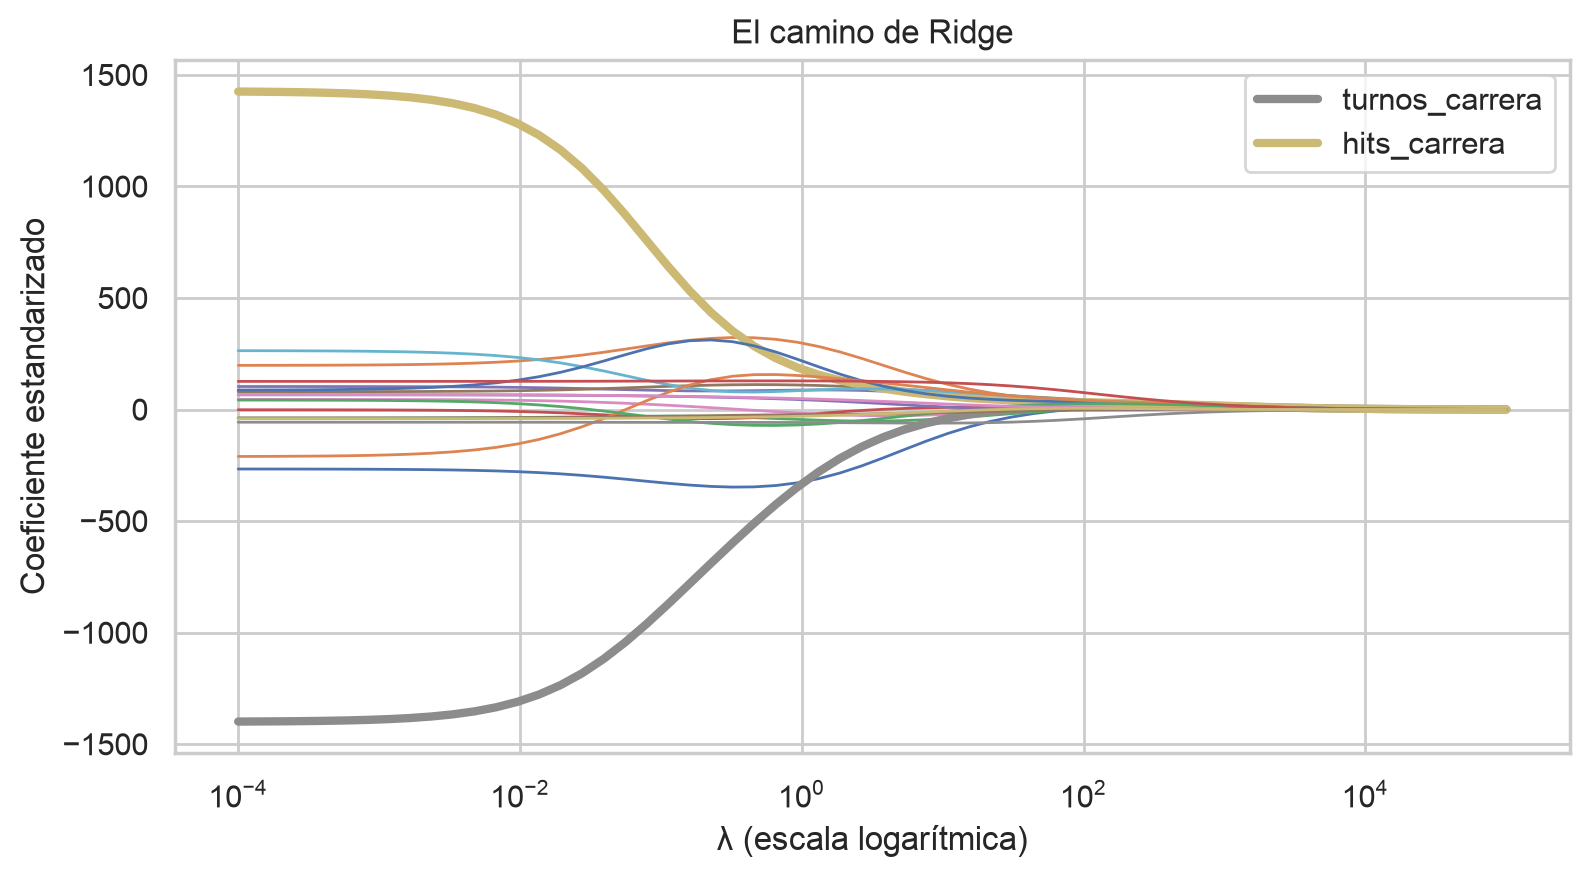

In [37]:
lambdas = np.logspace(-4, 5, 60)   # 60 valores de 0,0001 a 100.000, en escala logarítmica
camino_ridge = pd.DataFrame([Ridge(alpha=l).fit(Z_ent, y_ent).coef_ for l in lambdas],
                            index=lambdas, columns=X.columns)

fig, ax = plt.subplots(figsize=(9, 4.5))
for variable in X.columns:
    grueso = variable in ["turnos_carrera", "hits_carrera"]
    ax.plot(camino_ridge.index, camino_ridge[variable], lw=3 if grueso else 1,
            label=variable if grueso else None)
ax.set_xscale("log")
ax.set(xlabel="λ (escala logarítmica)", ylabel="Coeficiente estandarizado", title="El camino de Ridge")
ax.legend()
plt.show()

Y el error en entrenamiento y en prueba según $\lambda$:

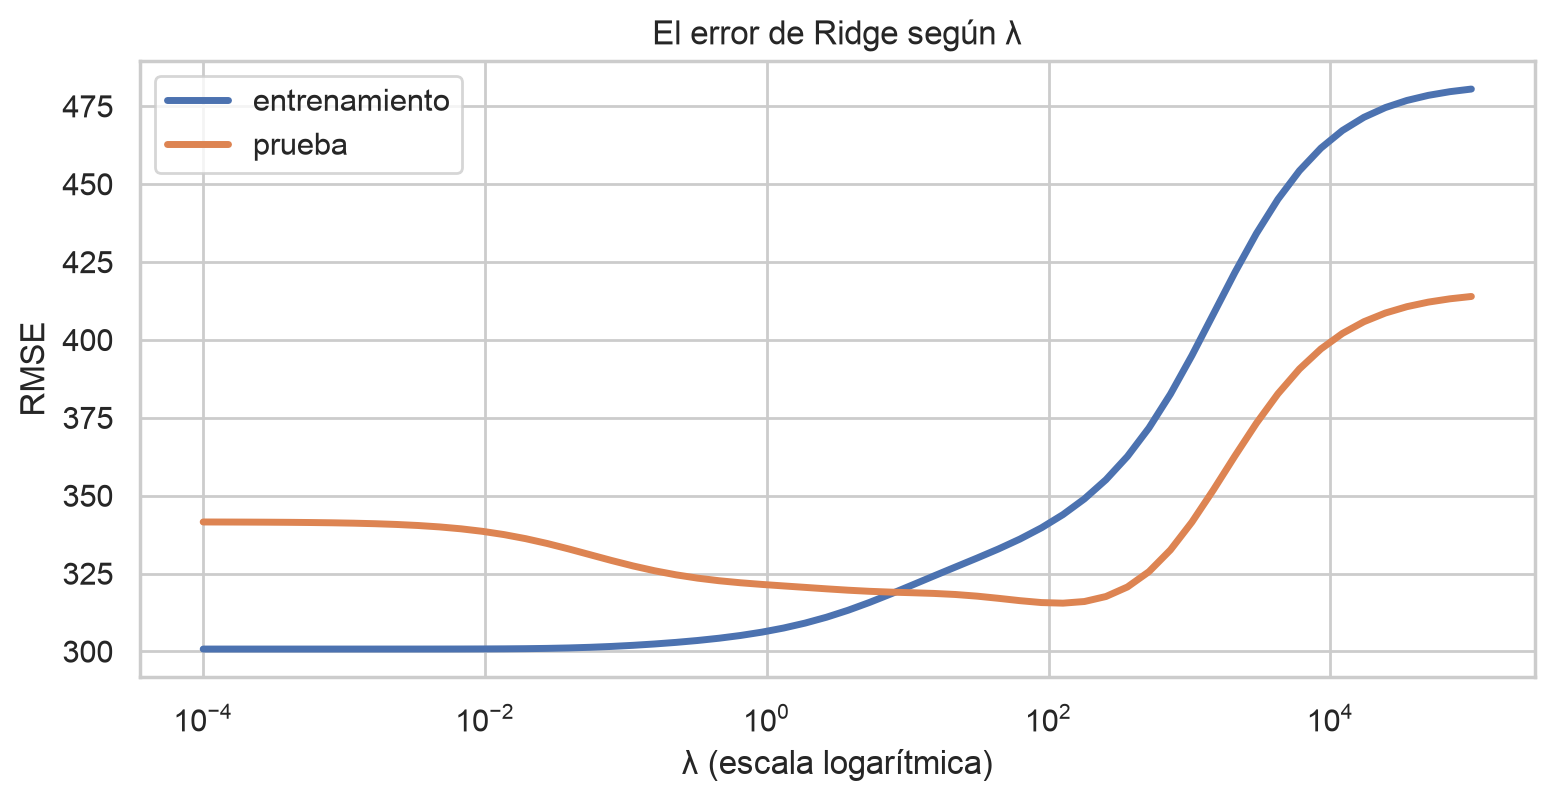

In [38]:
error_ent = [rmse(y_ent, Ridge(alpha=l).fit(Z_ent, y_ent).predict(Z_ent)) for l in lambdas]
error_pru = [rmse(y_pru, Ridge(alpha=l).fit(Z_ent, y_ent).predict(Z_pru)) for l in lambdas]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lambdas, error_ent, lw=2.5, label="entrenamiento")
ax.plot(lambdas, error_pru, lw=2.5, label="prueba")
ax.set_xscale("log")
ax.set(xlabel="λ (escala logarítmica)", ylabel="RMSE", title="El error de Ridge según λ")
ax.legend()
plt.show()

El error de entrenamiento solo sube: penalizar empeora el ajuste a los datos que el modelo ve. El de prueba baja y después sube. El mejor $\lambda$, sin embargo, no se puede elegir mirando la prueba: eso sería hacer trampa otra vez. Se elige con validación cruzada, en la sección 11.

## 10. Lasso

**Objetivo:** ver cómo Lasso lleva coeficientes exactamente a 0 y elige variables.

Lasso cambia el castigo por el valor absoluto de los coeficientes:

$$\sum_i (y_i - \hat{y}_i)^2 + \lambda \sum_j |b_j|$$

Ese cambio hace que algunos coeficientes lleguen exactamente a 0. Una advertencia: scikit-learn escala el castigo de Lasso distinto que el de Ridge, así que los valores de `alpha` de uno y otro no se comparan. Con $\lambda = 30$:

In [39]:
lasso = Lasso(alpha=30, max_iter=100000).fit(Z_ent, y_ent)
coef_lasso = pd.Series(lasso.coef_, index=X.columns)
print("variables con coeficiente distinto de 0:", (coef_lasso != 0).sum(), "de", len(coef_lasso))
coef_lasso[coef_lasso != 0].round(1)

variables con coeficiente distinto de 0: 6 de 19


hits                  49.300
bases_bolas           65.900
jonrones_carrera      18.500
impulsadas_carrera   180.300
outs_defensa         109.100
division_oeste       -42.100
dtype: float64

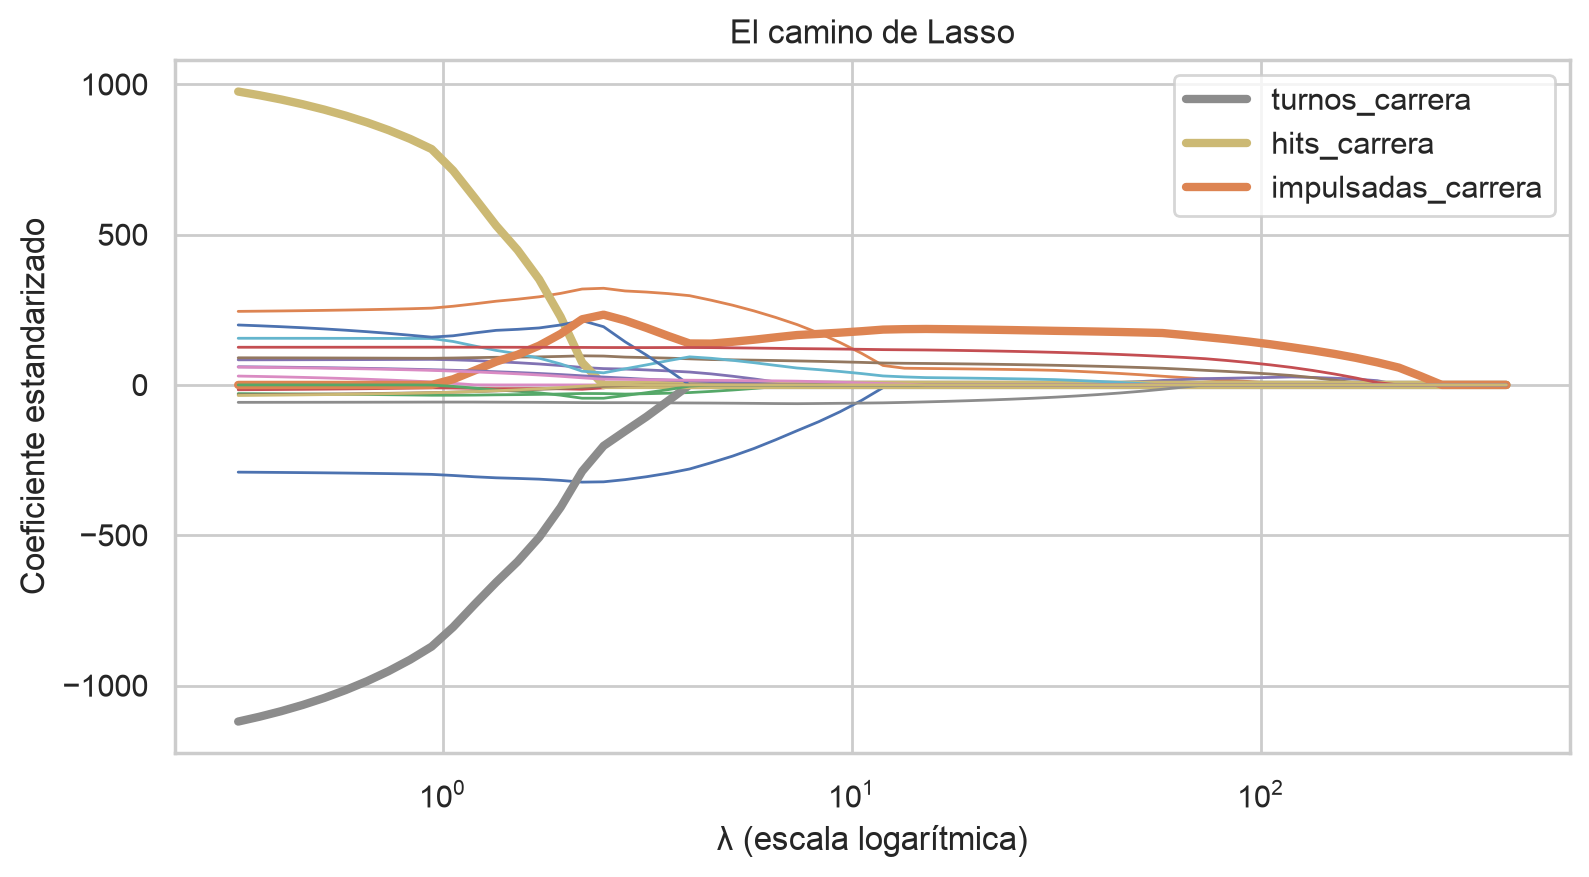

In [40]:
lambdas_lasso = np.logspace(-0.5, 2.6, 60)
camino_lasso = pd.DataFrame([Lasso(alpha=l, max_iter=100000).fit(Z_ent, y_ent).coef_ for l in lambdas_lasso],
                            index=lambdas_lasso, columns=X.columns)

fig, ax = plt.subplots(figsize=(9, 4.5))
for variable in X.columns:
    grueso = variable in ["turnos_carrera", "hits_carrera", "impulsadas_carrera"]
    ax.plot(camino_lasso.index, camino_lasso[variable], lw=3 if grueso else 1,
            label=variable if grueso else None)
ax.set_xscale("log")
ax.set(xlabel="λ (escala logarítmica)", ylabel="Coeficiente estandarizado", title="El camino de Lasso")
ax.legend()
plt.show()

## 11. Elegir λ con validación cruzada

**Objetivo:** elegir $\lambda$ sin tocar los datos de prueba.

La **validación cruzada** divide el entrenamiento en cinco partes. Para cada $\lambda$, ajusta el modelo con cuatro partes y mide el error en la quinta; lo repite cinco veces, cambiando la parte que valida, y promedia los cinco errores. Se elige el $\lambda$ con menor error promedio. `RidgeCV` y `LassoCV` hacen todo eso con `cv=5`:

In [41]:
ridge_cv = RidgeCV(alphas=np.logspace(-2, 5, 200), cv=5).fit(Z_ent, y_ent)
print(f"λ elegido para Ridge: {ridge_cv.alpha_:.1f}")

λ elegido para Ridge: 94.4


In [42]:
lasso_cv = LassoCV(cv=5, random_state=0, max_iter=100000).fit(Z_ent, y_ent)
coef_lasso_cv = pd.Series(lasso_cv.coef_, index=X.columns)
print(f"λ elegido para Lasso: {lasso_cv.alpha_:.1f}")
print("variables que conserva:", (coef_lasso_cv != 0).sum(), "de", len(coef_lasso_cv))
coef_lasso_cv[coef_lasso_cv != 0].round(1)

λ elegido para Lasso: 33.9
variables que conserva: 7 de 19


hits                  46.600
impulsadas             1.900
bases_bolas           64.400
jonrones_carrera      15.900
impulsadas_carrera   179.200
outs_defensa         107.100
division_oeste       -38.200
dtype: float64

Recién ahora, con cada $\lambda$ ya elegido, se mide el error en los datos de prueba, una sola vez:

In [43]:
resultados = pd.DataFrame({
    "RMSE en prueba": [rmse(y_pru, y_ent.mean()), rmse(y_pru, mco.predict(Z_pru)),
                       rmse(y_pru, ridge_cv.predict(Z_pru)), rmse(y_pru, lasso_cv.predict(Z_pru))],
    "variables usadas": [0, X.shape[1], X.shape[1], (coef_lasso_cv != 0).sum()],
}, index=["sin modelo (la media)", "mínimos cuadrados", "Ridge", "Lasso"])
resultados.round(0).astype(int)

,RMSE en prueba,variables usadas
sin modelo (la media),416,0
mínimos cuadrados,342,19
Ridge,316,19
Lasso,325,7


Ridge y Lasso se equivocan menos que mínimos cuadrados en los jugadores que no vieron, y Lasso lo logra con 7 de las 19 variables. ¿Es suerte de este reparto? Se repite todo con 20 repartos distintos:

In [44]:
filas = []
for semilla in range(1, 21):
    xe, xp, ye, yp = train_test_split(X, y, test_size=0.5, random_state=semilla)
    esc = StandardScaler().fit(xe)
    ze, zp = esc.transform(xe), esc.transform(xp)
    filas.append({
        "mínimos cuadrados": rmse(yp, LinearRegression().fit(ze, ye).predict(zp)),
        "Ridge": rmse(yp, RidgeCV(alphas=np.logspace(-2, 5, 200), cv=5).fit(ze, ye).predict(zp)),
        "Lasso": rmse(yp, LassoCV(cv=5, random_state=0, max_iter=100000).fit(ze, ye).predict(zp)),
    })
repartos = pd.DataFrame(filas)

print("RMSE promedio en prueba:")
print(repartos.mean().round(0).astype(int))
print("repartos en que Ridge gana a mínimos cuadrados:", (repartos["Ridge"] < repartos["mínimos cuadrados"]).sum(), "de 20")
print("repartos en que Lasso gana a mínimos cuadrados:", (repartos["Lasso"] < repartos["mínimos cuadrados"]).sum(), "de 20")

RMSE promedio en prueba:
mínimos cuadrados    371
Ridge                352
Lasso                358
dtype: int64
repartos en que Ridge gana a mínimos cuadrados: 17 de 20
repartos en que Lasso gana a mínimos cuadrados: 17 de 20


En 17 de los 20 repartos cada uno le gana a mínimos cuadrados: no es suerte. **¿Ridge o Lasso?** Ninguno es mejor siempre (James et al., p. 224). Lasso conviene si se sospecha que pocas variables importan, porque deja un modelo más simple; Ridge, si muchas aportan un poco o dicen casi lo mismo, porque estabiliza sus coeficientes sin descartar ninguna.

---

**Próxima clase (martes 22-sep), la última del módulo:** reducción de dimensionalidad (PCA) y las presentaciones orales del avance de cada equipo. El jueves 17 no hay clases, y el informe escrito de avance se entrega el viernes 25 de septiembre.